[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/01.quantum-foundations/02.bits-qubits-and-state/day06_derived_03_02_01_to_03_02_06_measurement_probability_vectors_lab.ipynb)


# 3-2. Measurement Probability Vector Practice


이 노트북은 `3-2-1.py`부터 `3-2-6.py`까지의 실습을 측정 확률 벡터 작업 단위로 정리한 버전입니다.

**확인한 원본 코드**
- `3-2-1.py`: Hadamard 회로의 counts를 확인합니다.
- `3-2-2.py`: counts에서 `P(0)`, `P(1)`을 계산합니다.
- `3-2-3.py`: `[P(0), P(1)]` probability vector를 만듭니다.
- `3-2-4.py`: helper 함수로 `|0>` 상태의 확률 벡터를 구합니다.
- `3-2-5.py`: helper 함수로 `H|0>` 상태의 확률 벡터를 구합니다.
- `3-2-6.py`: helper 함수로 `X|0>` 상태의 확률 벡터를 구합니다.

**학습 목표**
- counts를 확률로 바꾸는 과정을 이해합니다.
- `[P(0), P(1)]` 벡터가 1-qubit 측정 결과를 요약하는 방식임을 확인합니다.
- `|0>`, `H|0>`, `X|0>`의 probability vector를 비교합니다.


## Outline

1. 원본 파일 흐름 확인
2. Qiskit 실행 준비
3. counts를 probability vector로 변환하는 함수 작성
4. Hadamard 예제를 단계별로 재현
5. `|0>`, `H|0>`, `X|0>` 비교
6. 연습 문제


## 1. Source Map

여섯 파일은 같은 아이디어를 점진적으로 확장합니다.


In [1]:
SOURCE_FLOW = [
    ("3-2-1.py", "run a Hadamard circuit and print counts"),
    ("3-2-2.py", "convert counts into P(0) and P(1)"),
    ("3-2-3.py", "store [P(0), P(1)] as a probability vector"),
    ("3-2-4.py", "wrap the conversion in a helper for |0>"),
    ("3-2-5.py", "reuse the helper for H|0>"),
    ("3-2-6.py", "reuse the helper for X|0>"),
]

for source_name, description in SOURCE_FLOW:
    print(f"{source_name}: {description}")


3-2-1.py: run a Hadamard circuit and print counts
3-2-2.py: convert counts into P(0) and P(1)
3-2-3.py: store [P(0), P(1)] as a probability vector
3-2-4.py: wrap the conversion in a helper for |0>
3-2-5.py: reuse the helper for H|0>
3-2-6.py: reuse the helper for X|0>


## 2. Imports

이 실습은 Qiskit과 Qiskit Aer가 필요합니다. 새 Colab 런타임에서 import가 실패하면 설치 줄의 주석을 해제해 한 번 실행한 뒤, 런타임을 다시 시작하고 이어서 실행합니다.


In [2]:
# If Qiskit is missing in a fresh Colab runtime, uncomment and run once.
# %pip install -q qiskit qiskit-aer

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

SHOTS = 1000
SEED_SIMULATOR = 3201


## 3. Helper: Counts to Probability Vector

`counts`는 측정 결과의 횟수이고, probability vector는 이를 전체 shots로 나눈 `[P(0), P(1)]`입니다.


In [3]:
def run_and_get_prob_vector(
    circuit: QuantumCircuit,
    shots: int,
    seed: int,
) -> tuple[dict[str, int], list[float]]:
    simulator = AerSimulator(seed_simulator=seed)
    job = simulator.run(circuit, shots=shots)
    result = job.result()
    counts = {state: int(count) for state, count in result.get_counts().items()}
    total = sum(counts.values())
    p0 = counts.get("0", 0) / total
    p1 = counts.get("1", 0) / total
    return counts, [p0, p1]


## 4. Reproduce the Hadamard Progression

원본 `3-2-1.py`, `3-2-2.py`, `3-2-3.py`의 흐름을 한 셀에서 재현합니다.


In [4]:
hadamard_circuit = QuantumCircuit(1)
hadamard_circuit.h(0)
hadamard_circuit.measure_all()

hadamard_counts, hadamard_prob_vector = run_and_get_prob_vector(
    hadamard_circuit,
    SHOTS,
    SEED_SIMULATOR,
)

print(hadamard_circuit.draw(output="text"))
print("counts:", hadamard_counts)
print("P(0):", hadamard_prob_vector[0])
print("P(1):", hadamard_prob_vector[1])
print("probability vector:", hadamard_prob_vector)


        ┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 
counts: {'1': 506, '0': 494}
P(0): 0.494
P(1): 0.506
probability vector: [0.494, 0.506]


## 5. Compare Three One-Qubit States

원본 `3-2-4.py`, `3-2-5.py`, `3-2-6.py`는 같은 helper를 `|0>`, `H|0>`, `X|0>` 회로에 적용합니다.


In [5]:
zero_circuit = QuantumCircuit(1)
zero_circuit.measure_all()

h_circuit = QuantumCircuit(1)
h_circuit.h(0)
h_circuit.measure_all()

x_circuit = QuantumCircuit(1)
x_circuit.x(0)
x_circuit.measure_all()

state_experiments = [
    ("3-2-4.py", "|0>", zero_circuit),
    ("3-2-5.py", "H|0>", h_circuit),
    ("3-2-6.py", "X|0>", x_circuit),
]

prob_vectors = {}
for index, (source_name, label, circuit) in enumerate(state_experiments):
    counts, vector = run_and_get_prob_vector(circuit, SHOTS, SEED_SIMULATOR + index + 1)
    prob_vectors[label] = vector
    print(f"{source_name} ({label})")
    print("counts:", counts)
    print("[P(0), P(1)]:", vector)


3-2-4.py (|0>)
counts: {'0': 1000}
[P(0), P(1)]: [1.0, 0.0]
3-2-5.py (H|0>)
counts: {'1': 514, '0': 486}
[P(0), P(1)]: [0.486, 0.514]
3-2-6.py (X|0>)
counts: {'1': 1000}
[P(0), P(1)]: [0.0, 1.0]


## 6. Visualize Probability Vectors

각 상태의 `[P(0), P(1)]` 벡터를 막대그래프로 비교합니다.


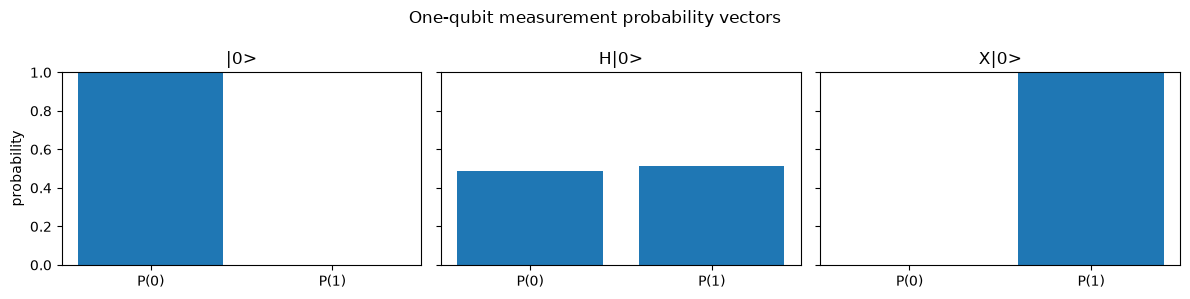

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

for axis, (_, label, _) in zip(axes, state_experiments):
    vector = prob_vectors[label]
    axis.bar(["P(0)", "P(1)"], vector)
    axis.set_title(label)
    axis.set_ylim(0, 1)

axes[0].set_ylabel("probability")
fig.suptitle("One-qubit measurement probability vectors")
fig.tight_layout()
plt.show()


## 7. Exercise

`X` gate 뒤에 `H` gate를 적용한 회로의 probability vector를 구해 보세요. `H|0>`과 같은지, 다른지 비교합니다.


In [7]:
exercise_circuit = QuantumCircuit(1)
exercise_circuit.x(0)
exercise_circuit.h(0)
exercise_circuit.measure_all()

exercise_counts, exercise_vector = run_and_get_prob_vector(
    exercise_circuit,
    SHOTS,
    SEED_SIMULATOR + 99,
)

print(exercise_circuit.draw(output="text"))
print("counts:", exercise_counts)
print("[P(0), P(1)]:", exercise_vector)


        ┌───┐┌───┐ ░ ┌─┐
     q: ┤ X ├┤ H ├─░─┤M├
        └───┘└───┘ ░ └╥┘
meas: 1/══════════════╩═
                      0 
counts: {'0': 484, '1': 516}
[P(0), P(1)]: [0.484, 0.516]


## Pitfall and Extension

**주의할 점**: probability vector는 측정 기준을 고정했을 때의 결과 요약입니다. 서로 다른 quantum state라도 특정 측정 기준에서는 같은 확률 벡터를 보일 수 있습니다.

**확장 실습**: `shots`를 `100`, `1000`, `5000`으로 바꾸어 probability vector의 흔들림이 어떻게 줄어드는지 비교해 보세요.
